# VG 评估结果综合分析 Notebook

这个 notebook 用于系统分析 `vg_eval.py` 产出的评估结果文件，重点回答以下问题：

- 模型整体表现如何，官方 `R@K / mR@K / ng-mR@K` 是多少
- 哪些 GT 三元组没有被模型预测出来
- 哪些三元组不在 GT 中，但模型却给出了预测
- 对于某个谓词，不同 `(subject, predicate, object)` 组合之间的精度差异如何
- 训练集里某个谓词出现得越多，模型对它的精确率是否越高
- 哪些错误更偏向长尾、零样本或谓词混淆

notebook 的说明文字、标题和关键代码注释均使用中文；函数和变量名保留英文，便于维护与复用。

## 1. 环境与路径配置

这一节负责：

- 设置实验结果目录
- 读取模型配置文件
- 指定 Top-K、IoU 阈值和导出目录
- 初始化绘图和表格展示风格

如果你第一次使用这个 notebook，请优先修改 `RESULT_DIR` 和 `CONFIG_PATH`。

In [37]:
import json
import math
import sys
import os
import warnings
from collections import Counter, defaultdict
from pathlib import Path
from typing import Dict, Iterable, List, Optional, Tuple

import numpy as np
import pandas as pd
import torch
from IPython.display import Markdown, display
from PIL import Image
from tqdm.auto import tqdm

try:
    import matplotlib.pyplot as plt
except Exception as exc:
    plt = None
    warnings.warn(f"未能导入 matplotlib，绘图相关单元将自动降级。详细原因: {exc}")

try:
    import seaborn as sns
    if plt is not None:
        sns.set_theme(style="whitegrid", context="talk")
except Exception:
    sns = None
    if plt is not None:
        plt.style.use("ggplot")

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 200)

REPO_ROOT = Path(os.path.dirname(Path.cwd()))
print(f"已设置仓库根目录: {REPO_ROOT}")

# 请在这里填写你的实验结果目录。该目录通常包含 eval_results.pytorch / result_dict.pytorch / visual_info.json。
RESULT_DIR = Path("/workspace/ccloud/sf/SDSGG/output/baseline/inference/VG_stanford_filtered_with_attribute_test")

# 请在这里填写实验对应的配置文件。
CONFIG_PATH = "/workspace/ccloud/sf/SDSGG/configs/e2e_relation_X_101_32_8_FPN_1x_total.yaml"

# Top-K 设置尽量和官方评估保持一致。
TOPK_LIST = [20, 50, 100]

# 如果这里设置为 None，后面会优先尝试从配置中读取官方阈值；读不到时回退到 0.5。
IOU_THRESH = None

# 导出目录为空时默认使用 RESULT_DIR / "analysis_exports"。
EXPORT_DIR = None

# 每个谓词默认展示多少个代表性案例。
SHOW_CASES_PER_PREDICATE = 3

# 是否在案例可视化中显示图片。
ENABLE_IMAGE_VIS = True

print(f"仓库根目录: {REPO_ROOT}")
print(f"结果目录: {RESULT_DIR}")
print(f"配置文件: {CONFIG_PATH}")

已设置仓库根目录: /workspace/ccloud/sf/SDSGG
仓库根目录: /workspace/ccloud/sf/SDSGG
结果目录: /workspace/ccloud/sf/SDSGG/output/baseline/inference/VG_stanford_filtered_with_attribute_test
配置文件: /workspace/ccloud/sf/SDSGG/configs/e2e_relation_X_101_32_8_FPN_1x_total.yaml


## 2. 加载评估结果与类别映射

这一节会读取：

- `eval_results.pytorch`：包含 `groundtruths` 和 `predictions`
- `result_dict.pytorch`：官方评估阶段累积出来的指标容器
- `visual_info.json`：图片路径和基础可视化信息
- VG 数据集字典文件：把对象类别 id 和谓词 id 转换成可读字符串
- VG 训练集标注：统计每个谓词和每个三元组在训练集中的出现次数

notebook 会对缺失文件做降级处理，并在文本提示中明确说明影响范围。

In [38]:
def show_message(text: str) -> None:
    """用统一格式输出中文提示信息。"""
    display(Markdown(text))
    
def safe_name(index: int, name_list: List[str], unknown_prefix: str) -> str:
    """安全地把 id 转换成字符串，避免越界导致 notebook 中断。"""
    if 0 <= int(index) < len(name_list):
        return name_list[int(index)]
    return f"{unknown_prefix}_{index}"

def ensure_path_exists(path: Path, description: str, required: bool = True) -> bool:
    """检查路径是否存在，并根据 required 决定是否抛出异常。"""
    if path.exists():
        return True
    message = f"{description}不存在: `{path}`"
    if required:
        raise FileNotFoundError(message)
    warnings.warn(message)
    return False

def load_eval_artifacts(result_dir: Path) -> dict:
    """读取评估输出文件，并对缺失的可选文件做降级处理。"""
    eval_path = result_dir / "eval_results.pytorch"
    result_dict_path = result_dir / "result_dict.pytorch"
    visual_info_path = result_dir / "visual_info.json"

    if not ensure_path_exists(result_dir, "结果目录", required=False):
        show_message("**提示：** 当前结果目录不存在，请先修改 `RESULT_DIR` 再重新运行本节。")
        return {}

    ensure_path_exists(eval_path, "eval_results.pytorch")
    eval_payload = torch.load(eval_path, map_location=torch.device("cpu"))
    result_dict = None
    visual_info = None

    if result_dict_path.exists():
        result_dict = torch.load(result_dict_path, map_location=torch.device("cpu"))
    else:
        warnings.warn("未找到 result_dict.pytorch，后续无法直接读取官方 mean recall 列表。")

    if visual_info_path.exists():
        with visual_info_path.open("r", encoding="utf-8") as f:
            visual_info = json.load(f)
    else:
        warnings.warn("未找到 visual_info.json，后续案例展示将缺少图片路径信息。")

    return {
        "groundtruths": eval_payload["groundtruths"],
        "predictions": eval_payload["predictions"],
        "result_dict": result_dict,
        "visual_info": visual_info,
        "eval_path": eval_path,
        "result_dict_path": result_dict_path,
        "visual_info_path": visual_info_path,
    }

def build_visual_lookup(visual_info: Optional[list]) -> dict:
    """把 visual_info 转成以 image_id 为键的索引字典。"""
    if not visual_info:
        return {}
    return {idx: item for idx, item in enumerate(visual_info)}

def resolve_iou_threshold(runtime_cfg, user_value: Optional[float]) -> float:
    """优先使用用户显式设置的阈值，否则从配置读取，最后回退到 0.5。"""
    if user_value is not None:
        return float(user_value)
    try:
        return float(runtime_cfg.TEST.RELATION.IOU_THRESHOLD)
    except Exception:
        return 0.5

In [39]:
sys.path.insert(0, str(REPO_ROOT))
from maskrcnn_benchmark.data.build import build_dataset
from maskrcnn_benchmark.config import cfg
from maskrcnn_benchmark.utils.imports import import_file
from maskrcnn_benchmark.data import datasets as D

cfg.merge_from_file(str(CONFIG_PATH))

dataset_names = cfg.DATASETS.TRAIN
paths_catalog = import_file(
        "maskrcnn_benchmark.config.paths_catalog", cfg.PATHS_CATALOG, True
    )
DatasetCatalog = paths_catalog.DatasetCatalog
assert len(dataset_names) == 1, "当前分析脚本仅支持单数据集设置，请确保 cfg.DATASETS.TRAIN 中仅包含一个数据集名称。"

for dataset_name in dataset_names:
        data = DatasetCatalog.get(dataset_name, cfg)
        factory = getattr(D, data["factory"])
        args = data["args"]

        # Remove it because not part of the original repo (factory cant deal with additional parameters...).
        if "capgraphs_file" in args.keys():
            del args["capgraphs_file"]
        dataset = factory(**args)
        statistics = dataset.get_statistics()

ind_to_classes, ind_to_predicates = dataset.ind_to_classes, dataset.ind_to_predicates
artifacts = load_eval_artifacts(RESULT_DIR)

context = None
iou_threshold = resolve_iou_threshold(cfg, IOU_THRESH)
if artifacts:
    if not ind_to_classes or not ind_to_predicates:
        raise FileNotFoundError("结果文件已找到，但 VG 字典文件缺失，无法把类别 id 转成可读字符串。请检查 CONFIG_PATH 和数据集路径。")

    zeroshot_path = REPO_ROOT / "maskrcnn_benchmark" / "data" / "datasets" / "evaluation" / "vg" / "zeroshot_triplet.pytorch"
    zeroshot_triplets = set()
    if zeroshot_path.exists():
        zeroshot_triplets = {
            tuple(map(int, row))
            for row in torch.load(zeroshot_path, map_location=torch.device("cpu")).long().numpy()
        }

    export_dir = Path(EXPORT_DIR) if EXPORT_DIR else RESULT_DIR / "analysis_exports"
    context = {
        "artifacts": artifacts,
        "iou_threshold": iou_threshold,
        "visual_lookup": build_visual_lookup(artifacts["visual_info"]),
        "train_statistics": statistics,
        "topk_list": sorted(set(int(v) for v in TOPK_LIST)),
        "zeroshot_triplets": zeroshot_triplets,
        "export_dir": export_dir,
    }

VG_stanford_filtered_with_attribute
['__background__', 'airplane', 'animal', 'arm', 'bag', 'banana', 'basket', 'beach', 'bear', 'bed', 'bench', 'bike', 'bird', 'board', 'boat', 'book', 'boot', 'bottle', 'bowl', 'box', 'boy', 'branch', 'building', 'bus', 'cabinet', 'cap', 'car', 'cat', 'chair', 'child', 'clock', 'coat', 'counter', 'cow', 'cup', 'curtain', 'desk', 'dog', 'door', 'drawer', 'ear', 'elephant', 'engine', 'eye', 'face', 'fence', 'finger', 'flag', 'flower', 'food', 'fork', 'fruit', 'giraffe', 'girl', 'glass', 'glove', 'guy', 'hair', 'hand', 'handle', 'hat', 'head', 'helmet', 'hill', 'horse', 'house', 'jacket', 'jean', 'kid', 'kite', 'lady', 'lamp', 'laptop', 'leaf', 'leg', 'letter', 'light', 'logo', 'man', 'men', 'motorcycle', 'mountain', 'mouth', 'neck', 'nose', 'number', 'orange', 'pant', 'paper', 'paw', 'people', 'person', 'phone', 'pillow', 'pizza', 'plane', 'plant', 'plate', 'player', 'pole', 'post', 'pot', 'racket', 'railing', 'rock', 'roof', 'room', 'screen', 'seat', 's

{0: 0, 1: 8411, 3: 224, 6: 2109, 7: 1586, 8: 13047, 9: 652, 10: 511, 11: 1705, 12: 485, 13: 512, 16: 1116, 17: 198, 19: 807, 20: 50000, 21: 11482, 22: 24470, 23: 3808, 25: 1026, 27: 128, 29: 20759, 30: 32770, 31: 50000, 33: 1277, 35: 641, 37: 134, 38: 4507, 40: 5355, 41: 2496, 42: 327, 43: 4732, 46: 1322, 47: 907, 48: 48582, 49: 4939, 50: 12215}
train


100%|██████████| 53160/53160 [00:08<00:00, 6403.01it/s]


## 3. 还原官方评估口径

下面这组函数会复现 `vg_eval.py / sgg_eval.py` 的核心逻辑：

- GT 三元组：`(subject_class, predicate, object_class)`
- 预测三元组：`(subject_class, predicate_argmax, object_class)`
- 匹配条件：三元组标签完全一致，且主语框和宾语框的 IoU 同时不低于阈值

为了保证和官方结果尽量一致：

- graph-constrained 分析保留 `eval_results.pytorch` 中原始关系顺序
- no-graph-constraint 分析会重建所有 `(pair, predicate)` 候选并按综合分数排序
- 所有统计都保留 `count / hit / precision / recall` 等基础计数，便于复查

In [40]:
def compute_box_iou_matrix(boxes1: np.ndarray, boxes2: np.ndarray) -> np.ndarray:
    """计算两组框之间的 IoU 矩阵。"""
    if boxes1.size == 0 or boxes2.size == 0:
        return np.zeros((len(boxes1), len(boxes2)), dtype=np.float32)

    boxes1 = boxes1.astype(np.float32)
    boxes2 = boxes2.astype(np.float32)

    area1 = np.clip(boxes1[:, 2] - boxes1[:, 0] + 1, a_min=0, a_max=None) * np.clip(boxes1[:, 3] - boxes1[:, 1] + 1, a_min=0, a_max=None)
    area2 = np.clip(boxes2[:, 2] - boxes2[:, 0] + 1, a_min=0, a_max=None) * np.clip(boxes2[:, 3] - boxes2[:, 1] + 1, a_min=0, a_max=None)

    lt = np.maximum(boxes1[:, None, :2], boxes2[None, :, :2])
    rb = np.minimum(boxes1[:, None, 2:], boxes2[None, :, 2:])
    wh = np.clip(rb - lt + 1, a_min=0, a_max=None)
    inter = wh[:, :, 0] * wh[:, :, 1]
    union = area1[:, None] + area2[None, :] - inter
    return np.divide(inter, union, out=np.zeros_like(inter), where=union > 0)


def intersect_2d_numpy(arr1: np.ndarray, arr2: np.ndarray) -> np.ndarray:
    """判断 arr1 中每一行是否与 arr2 中每一行完全相等。"""
    if arr1.size == 0 or arr2.size == 0:
        return np.zeros((len(arr1), len(arr2)), dtype=bool)
    return (arr1[:, None, :] == arr2[None, :, :]).all(axis=-1)


def build_triplets(relations: np.ndarray, classes: np.ndarray, boxes: np.ndarray, predicate_scores: Optional[np.ndarray] = None, class_scores: Optional[np.ndarray] = None):
    """把 (sub_idx, obj_idx, pred_id) 转成 triplet 形式。"""
    if len(relations) == 0:
        empty_triplets = np.zeros((0, 3), dtype=np.int64)
        empty_boxes = np.zeros((0, 8), dtype=np.float32)
        empty_scores = np.zeros((0, 3), dtype=np.float32) if predicate_scores is not None and class_scores is not None else None
        return empty_triplets, empty_boxes, empty_scores

    sub_id = relations[:, 0].astype(np.int64)
    obj_id = relations[:, 1].astype(np.int64)
    pred_label = relations[:, 2].astype(np.int64)

    triplets = np.column_stack((classes[sub_id], pred_label, classes[obj_id]))
    triplet_boxes = np.column_stack((boxes[sub_id], boxes[obj_id])).astype(np.float32)

    triplet_scores = None
    if predicate_scores is not None and class_scores is not None:
        triplet_scores = np.column_stack((
            class_scores[sub_id],
            predicate_scores,
            class_scores[obj_id],
        )).astype(np.float32)

    return triplets, triplet_boxes, triplet_scores


def compute_pred_matches(gt_triplets: np.ndarray, pred_triplets: np.ndarray, gt_triplet_boxes: np.ndarray, pred_triplet_boxes: np.ndarray, iou_thresh: float) -> List[List[int]]:
    """
    复现官方评估中的 GT-预测匹配关系。

    返回值 pred_to_gt 的长度等于预测关系数，其中每个元素是当前预测命中的 GT 索引列表。
    """
    keeps = intersect_2d_numpy(gt_triplets, pred_triplets)
    gt_has_match = keeps.any(axis=1)
    pred_to_gt = [[] for _ in range(len(pred_triplets))]

    for gt_ind, gt_box, keep_inds in zip(np.where(gt_has_match)[0], gt_triplet_boxes[gt_has_match], keeps[gt_has_match]):
        pred_indices = np.where(keep_inds)[0]
        if len(pred_indices) == 0:
            continue
        boxes = pred_triplet_boxes[pred_indices]
        gt_sub_box = gt_box[:4][None, :]
        gt_obj_box = gt_box[4:][None, :]
        pred_sub_boxes = boxes[:, :4]
        pred_obj_boxes = boxes[:, 4:]
        sub_iou = compute_box_iou_matrix(gt_sub_box, pred_sub_boxes)[0]
        obj_iou = compute_box_iou_matrix(gt_obj_box, pred_obj_boxes)[0]
        matched_pred_indices = pred_indices[(sub_iou >= iou_thresh) & (obj_iou >= iou_thresh)]
        for pred_index in matched_pred_indices.tolist():
            pred_to_gt[pred_index].append(int(gt_ind))

    return pred_to_gt


def flatten_top_scores(score_matrix: np.ndarray, limit: int) -> np.ndarray:
    """对二维分数矩阵做降序展开，返回前 limit 个位置的二维索引。"""
    if score_matrix.size == 0:
        return np.zeros((0, 2), dtype=np.int64)
    flat_indices = np.argsort(score_matrix.reshape(-1))[::-1]
    flat_indices = flat_indices[:limit]
    return np.column_stack(np.unravel_index(flat_indices, score_matrix.shape))


def build_nogc_predictions(pred_rel_inds: np.ndarray, rel_scores: np.ndarray, obj_scores: np.ndarray, top_limit: int) -> dict:
    """复现 no-graph-constraint 评估时的候选排序。"""
    if len(pred_rel_inds) == 0:
        return {
            "pred_rels": np.zeros((0, 3), dtype=np.int64),
            "predicate_scores": np.zeros((0,), dtype=np.float32),
            "triplet_scores": np.zeros((0,), dtype=np.float32),
            "pair_rank_source": np.zeros((0,), dtype=np.int64),
        }

    obj_scores_per_rel = obj_scores[pred_rel_inds].prod(axis=1)
    overall_scores = obj_scores_per_rel[:, None] * rel_scores[:, 1:]
    top_indices = flatten_top_scores(overall_scores, top_limit)

    pred_rels = np.column_stack((
        pred_rel_inds[top_indices[:, 0]],
        top_indices[:, 1] + 1,
    )).astype(np.int64)
    predicate_scores = rel_scores[top_indices[:, 0], top_indices[:, 1] + 1].astype(np.float32)
    triplet_scores = overall_scores[top_indices[:, 0], top_indices[:, 1]].astype(np.float32)
    pair_rank_source = top_indices[:, 0].astype(np.int64)

    return {
        "pred_rels": pred_rels,
        "predicate_scores": predicate_scores,
        "triplet_scores": triplet_scores,
        "pair_rank_source": pair_rank_source,
    }


def union_pred_to_gt(pred_to_gt: List[List[int]], topk: int) -> List[int]:
    """把前 topk 个预测命中的 GT 索引做并集。"""
    if topk <= 0 or len(pred_to_gt) == 0:
        return []
    merged = set()
    for matched_gt in pred_to_gt[: min(topk, len(pred_to_gt))]:
        merged.update(int(item) for item in matched_gt)
    return sorted(merged)

In [41]:
def analyze_one_image(
    image_id: int,
    groundtruth,
    prediction,
    visual_lookup: dict,
    ind_to_classes: List[str],
    ind_to_predicates: List[str],
    iou_thresh: float,
    topk_list: List[int],
) -> dict:
    """
    对单张图片做关系级分析，输出 GT 记录、graph-constrained 预测记录、no-graph 预测记录和谓词混淆线索。
    """
    gt_boxes = groundtruth.convert("xyxy").bbox.detach().cpu().numpy()
    gt_classes = groundtruth.get_field("labels").long().detach().cpu().numpy()
    gt_rels = groundtruth.get_field("relation_tuple").long().detach().cpu().numpy()

    pred_boxes = prediction.convert("xyxy").bbox.detach().cpu().numpy()
    pred_classes = prediction.get_field("pred_labels").long().detach().cpu().numpy()
    obj_scores = prediction.get_field("pred_scores").detach().cpu().numpy()
    pred_rel_inds = prediction.get_field("rel_pair_idxs").long().detach().cpu().numpy()
    rel_scores = prediction.get_field("pred_rel_scores").detach().cpu().numpy()

    max_topk = max(topk_list) if topk_list else 100
    image_info = visual_lookup.get(image_id, {})
    img_file = image_info.get("img_file")

    gt_triplets, gt_triplet_boxes, _ = build_triplets(gt_rels, gt_classes, gt_boxes)

    if len(pred_rel_inds) > 0:
        gc_predicates = 1 + rel_scores[:, 1:].argmax(axis=1)
        gc_predicate_scores = rel_scores[:, 1:].max(axis=1)
        gc_pred_rels = np.column_stack((pred_rel_inds, gc_predicates)).astype(np.int64)
        gc_triplets, gc_triplet_boxes, gc_triplet_scores_3 = build_triplets(
            gc_pred_rels,
            pred_classes,
            pred_boxes,
            predicate_scores=gc_predicate_scores,
            class_scores=obj_scores,
        )
        gc_triplet_scores = gc_triplet_scores_3.prod(axis=1) if len(gc_triplet_scores_3) > 0 else np.zeros((0,), dtype=np.float32)
        gc_pred_to_gt = compute_pred_matches(
            gt_triplets=gt_triplets,
            pred_triplets=gc_triplets,
            gt_triplet_boxes=gt_triplet_boxes,
            pred_triplet_boxes=gc_triplet_boxes,
            iou_thresh=iou_thresh,
        )
    else:
        gc_pred_rels = np.zeros((0, 3), dtype=np.int64)
        gc_predicate_scores = np.zeros((0,), dtype=np.float32)
        gc_triplets = np.zeros((0, 3), dtype=np.int64)
        gc_triplet_boxes = np.zeros((0, 8), dtype=np.float32)
        gc_triplet_scores = np.zeros((0,), dtype=np.float32)
        gc_pred_to_gt = []

    nogc_payload = build_nogc_predictions(pred_rel_inds, rel_scores, obj_scores, top_limit=max(100, max_topk))
    nogc_pred_rels = nogc_payload["pred_rels"]
    nogc_predicate_scores = nogc_payload["predicate_scores"]
    nogc_triplet_scores = nogc_payload["triplet_scores"]

    if len(nogc_pred_rels) > 0:
        nogc_triplets, nogc_triplet_boxes, _ = build_triplets(
            nogc_pred_rels,
            pred_classes,
            pred_boxes,
            predicate_scores=nogc_predicate_scores,
            class_scores=obj_scores,
        )
        nogc_pred_to_gt = compute_pred_matches(
            gt_triplets=gt_triplets,
            pred_triplets=nogc_triplets,
            gt_triplet_boxes=gt_triplet_boxes,
            pred_triplet_boxes=nogc_triplet_boxes,
            iou_thresh=iou_thresh,
        )
    else:
        nogc_triplets = np.zeros((0, 3), dtype=np.int64)
        nogc_triplet_boxes = np.zeros((0, 8), dtype=np.float32)
        nogc_pred_to_gt = []

    matched_gt_per_k = {k: set(union_pred_to_gt(gc_pred_to_gt, k)) for k in topk_list}
    matched_gt_nogc_per_k = {k: set(union_pred_to_gt(nogc_pred_to_gt, k)) for k in topk_list}

    gt_rows = []
    confusion_rows = []
    for gt_index, (sub_idx, obj_idx, predicate_id) in enumerate(gt_rels):
        sub_idx = int(sub_idx)
        obj_idx = int(obj_idx)
        predicate_id = int(predicate_id)
        subject_id = int(gt_classes[sub_idx])
        object_id = int(gt_classes[obj_idx])
        triplet_key = (subject_id, predicate_id, object_id)
        triplet_str = f"{safe_name(subject_id, ind_to_classes, 'unknown_obj')} - {safe_name(predicate_id, ind_to_predicates, 'unknown_pred')} - {safe_name(object_id, ind_to_classes, 'unknown_obj')}"

        row = {
            "image_id": image_id,
            "img_file": img_file,
            "gt_index": gt_index,
            "subject_box_index": sub_idx,
            "object_box_index": obj_idx,
            "subject_id": subject_id,
            "predicate_id": predicate_id,
            "object_id": object_id,
            "subject_name": safe_name(subject_id, ind_to_classes, "unknown_obj"),
            "predicate_name": safe_name(predicate_id, ind_to_predicates, "unknown_pred"),
            "object_name": safe_name(object_id, ind_to_classes, "unknown_obj"),
            "triplet_key": triplet_key,
            "triplet_str": triplet_str,
            "gt_sub_box": gt_boxes[sub_idx].tolist(),
            "gt_obj_box": gt_boxes[obj_idx].tolist(),
        }

        for k in topk_list:
            row[f"matched_at_{k}"] = gt_index in matched_gt_per_k[k]
            row[f"matched_nogc_at_{k}"] = gt_index in matched_gt_nogc_per_k[k]

        best_candidate = None
        if len(gc_pred_rels) > 0:
            candidate_indices = []
            for pred_index, pred_rel in enumerate(gc_pred_rels):
                pred_sub_idx, pred_obj_idx, pred_predicate = [int(v) for v in pred_rel]
                pred_subject_id = int(pred_classes[pred_sub_idx])
                pred_object_id = int(pred_classes[pred_obj_idx])
                if pred_subject_id != subject_id or pred_object_id != object_id:
                    continue
                subject_iou = float(compute_box_iou_matrix(gt_boxes[sub_idx][None, :], pred_boxes[pred_sub_idx][None, :])[0, 0])
                object_iou = float(compute_box_iou_matrix(gt_boxes[obj_idx][None, :], pred_boxes[pred_obj_idx][None, :])[0, 0])
                if subject_iou >= iou_thresh and object_iou >= iou_thresh:
                    candidate_indices.append((pred_index, subject_iou, object_iou))

            if candidate_indices:
                pred_index, subject_iou, object_iou = sorted(
                    candidate_indices,
                    key=lambda item: gc_triplet_scores[item[0]],
                    reverse=True,
                )[0]
                candidate_predicate = int(gc_pred_rels[pred_index][2])
                best_candidate = {
                    "candidate_pred_index": pred_index,
                    "candidate_predicate_id": candidate_predicate,
                    "candidate_predicate_name": safe_name(candidate_predicate, ind_to_predicates, "unknown_pred"),
                    "candidate_triplet_score": float(gc_triplet_scores[pred_index]),
                    "candidate_predicate_score": float(gc_predicate_scores[pred_index]),
                    "candidate_subject_iou": subject_iou,
                    "candidate_object_iou": object_iou,
                }

        confusion_rows.append({
            "image_id": image_id,
            "img_file": img_file,
            "gt_index": gt_index,
            "gt_predicate_id": predicate_id,
            "gt_predicate_name": safe_name(predicate_id, ind_to_predicates, "unknown_pred"),
            "gt_triplet_str": triplet_str,
            "matched_at_100": row.get("matched_at_100", False),
            "candidate_predicate_id": best_candidate["candidate_predicate_id"] if best_candidate else -1,
            "candidate_predicate_name": best_candidate["candidate_predicate_name"] if best_candidate else "__no_prediction__",
            "candidate_triplet_score": best_candidate["candidate_triplet_score"] if best_candidate else np.nan,
        })
        gt_rows.append(row)

    pred_rows = []
    for pred_index, pred_rel in enumerate(gc_pred_rels):
        pred_sub_idx, pred_obj_idx, predicate_id = [int(v) for v in pred_rel]
        subject_id = int(pred_classes[pred_sub_idx])
        object_id = int(pred_classes[pred_obj_idx])
        triplet_key = (subject_id, predicate_id, object_id)
        row = {
            "image_id": image_id,
            "img_file": img_file,
            "pred_index": pred_index,
            "subject_box_index": pred_sub_idx,
            "object_box_index": pred_obj_idx,
            "subject_id": subject_id,
            "predicate_id": predicate_id,
            "object_id": object_id,
            "subject_name": safe_name(subject_id, ind_to_classes, "unknown_obj"),
            "predicate_name": safe_name(predicate_id, ind_to_predicates, "unknown_pred"),
            "object_name": safe_name(object_id, ind_to_classes, "unknown_obj"),
            "triplet_key": triplet_key,
            "triplet_str": f"{safe_name(subject_id, ind_to_classes, 'unknown_obj')} - {safe_name(predicate_id, ind_to_predicates, 'unknown_pred')} - {safe_name(object_id, ind_to_classes, 'unknown_obj')}",
            "triplet_score": float(gc_triplet_scores[pred_index]),
            "predicate_score": float(gc_predicate_scores[pred_index]),
            "matched_gt_indices": [int(v) for v in gc_pred_to_gt[pred_index]],
        }
        for k in topk_list:
            row[f"is_top_{k}"] = pred_index < k
            row[f"correct_at_{k}"] = pred_index < k and len(gc_pred_to_gt[pred_index]) > 0
        pred_rows.append(row)

    nogc_rows = []
    for pred_index, pred_rel in enumerate(nogc_pred_rels):
        pred_sub_idx, pred_obj_idx, predicate_id = [int(v) for v in pred_rel]
        subject_id = int(pred_classes[pred_sub_idx])
        object_id = int(pred_classes[pred_obj_idx])
        triplet_key = (subject_id, predicate_id, object_id)
        row = {
            "image_id": image_id,
            "img_file": img_file,
            "pred_index": pred_index,
            "subject_box_index": pred_sub_idx,
            "object_box_index": pred_obj_idx,
            "subject_id": subject_id,
            "predicate_id": predicate_id,
            "object_id": object_id,
            "subject_name": safe_name(subject_id, ind_to_classes, "unknown_obj"),
            "predicate_name": safe_name(predicate_id, ind_to_predicates, "unknown_pred"),
            "object_name": safe_name(object_id, ind_to_classes, "unknown_obj"),
            "triplet_key": triplet_key,
            "triplet_str": f"{safe_name(subject_id, ind_to_classes, 'unknown_obj')} - {safe_name(predicate_id, ind_to_predicates, 'unknown_pred')} - {safe_name(object_id, ind_to_classes, 'unknown_obj')}",
            "triplet_score": float(nogc_triplet_scores[pred_index]),
            "predicate_score": float(nogc_predicate_scores[pred_index]),
            "pair_rank_source": int(nogc_payload["pair_rank_source"][pred_index]),
            "matched_gt_indices": [int(v) for v in nogc_pred_to_gt[pred_index]],
        }
        for k in topk_list:
            row[f"is_top_{k}"] = pred_index < k
            row[f"correct_at_{k}"] = pred_index < k and len(nogc_pred_to_gt[pred_index]) > 0
        nogc_rows.append(row)

    return {
        "gt_rows": gt_rows,
        "pred_rows": pred_rows,
        "nogc_rows": nogc_rows,
        "confusion_rows": confusion_rows,
    }


if context is not None:
    analysis_rows = {
        "gt_rows": [],
        "pred_rows": [],
        "nogc_rows": [],
        "confusion_rows": [],
    }

    for image_id, (groundtruth, prediction) in tqdm(
        enumerate(zip(context["artifacts"]["groundtruths"], context["artifacts"]["predictions"])),
        total=len(context["artifacts"]["groundtruths"]),
        desc="逐图构建分析表",
    ):
        analyzed = analyze_one_image(
            image_id=image_id,
            groundtruth=groundtruth,
            prediction=prediction,
            visual_lookup=context["visual_lookup"],
            ind_to_classes=ind_to_classes,
            ind_to_predicates=ind_to_predicates,
            iou_thresh=context["iou_threshold"],
            topk_list=context["topk_list"],
        )
        for key in analysis_rows:
            analysis_rows[key].extend(analyzed[key])

    gt_df = pd.DataFrame(analysis_rows["gt_rows"])
    pred_df = pd.DataFrame(analysis_rows["pred_rows"])
    nogc_pred_df = pd.DataFrame(analysis_rows["nogc_rows"])
    confusion_df = pd.DataFrame(analysis_rows["confusion_rows"])

    context["tables"] = {
        "gt_df": gt_df,
        "pred_df": pred_df,
        "nogc_pred_df": nogc_pred_df,
        "confusion_df": confusion_df,
    }

    show_message(
        f"""
        **分析表构建完成**

        - GT 关系数：`{len(gt_df)}`  
        - graph-constrained 预测关系数：`{len(pred_df)}`  
        - no-graph 预测关系数：`{len(nogc_pred_df)}`  
        - 谓词混淆线索数：`{len(confusion_df)}`
        """
    )

逐图构建分析表: 100%|██████████| 1425/1425 [00:12<00:00, 113.13it/s]



        **分析表构建完成**

        - GT 关系数：`2358`  
        - graph-constrained 预测关系数：`370960`  
        - no-graph 预测关系数：`141820`  
        - 谓词混淆线索数：`2358`
        

## 4. 全局指标汇总

这里优先展示官方 `result_dict.pytorch` 中已经保存的结果，因为它和训练/测试脚本完全同口径。

如果缺少 `result_dict.pytorch`，则 notebook 会退化为展示基于当前分析表重新聚合得到的近似指标，并明确说明与官方结果的差异。

In [42]:
def detect_eval_mode(result_dict: Optional[dict]) -> Optional[str]:
    """从官方 result_dict 中推断当前评估模式，例如 predcls / sgcls / sgdet。"""
    if not result_dict:
        return None
    for key in result_dict:
        if key.endswith("_recall") and not key.endswith("_zeroshot_recall"):
            return key.replace("_recall", "")
    return None


def summarize_official_metrics(result_dict: Optional[dict]) -> pd.DataFrame:
    """把官方 result_dict 整理成更容易阅读的长表。"""
    if not result_dict:
        return pd.DataFrame()

    mode = detect_eval_mode(result_dict)
    if mode is None:
        return pd.DataFrame()

    metric_rows = []
    for metric_name, metric_value in result_dict.items():
        if not metric_name.startswith(mode):
            continue
        suffix = metric_name.replace(f"{mode}_", "")
        if isinstance(metric_value, dict):
            for k, values in metric_value.items():
                scalar = safe_metric_to_scalar(values)
                if pd.isna(scalar):
                    continue
                metric_rows.append({
                    "mode": mode,
                    "metric_name": suffix,
                    "k": int(k),
                    "value": scalar,
                })
    return pd.DataFrame(metric_rows).sort_values(["metric_name", "k"]).reset_index(drop=True)


def safe_metric_to_scalar(values) -> float:
    """
    尝试把官方 result_dict 中的指标项转换成单个浮点数。

    只接受以下两类值：
    - 单个标量
    - 一维数值列表

    对于 `mean_recall_collect` 这类嵌套列表结构，直接返回 NaN 并跳过，
    避免 notebook 在展示官方指标时中断。
    """
    if isinstance(values, (int, float, np.integer, np.floating)):
        return float(values)

    if isinstance(values, np.ndarray):
        if values.ndim == 0:
            return float(values.item())
        if values.ndim == 1 and np.issubdtype(values.dtype, np.number):
            return float(np.mean(values)) if len(values) > 0 else np.nan
        return np.nan

    if isinstance(values, list):
        if len(values) == 0:
            return np.nan
        if all(isinstance(item, (int, float, np.integer, np.floating)) for item in values):
            return float(np.mean(values))
        return np.nan

    try:
        return float(values)
    except Exception:
        return np.nan


def summarize_notebook_recall(gt_df: pd.DataFrame, pred_df: pd.DataFrame, topk_list: List[int]) -> pd.DataFrame:
    """在 result_dict 缺失时，给出一个便于参考的数据集级近似汇总。"""
    rows = []
    total_gt = len(gt_df)
    total_images = gt_df["image_id"].nunique() if len(gt_df) > 0 else 0

    for k in topk_list:
        matched_count = int(gt_df[f"matched_at_{k}"].sum()) if total_gt > 0 else 0
        pred_topk_count = int(pred_df[f"is_top_{k}"].sum()) if len(pred_df) > 0 else 0
        tp_count = int(pred_df[f"correct_at_{k}"].sum()) if len(pred_df) > 0 else 0
        rows.append({
            "mode": "notebook",
            "metric_name": "dataset_level_recall",
            "k": k,
            "value": matched_count / total_gt if total_gt > 0 else np.nan,
        })
        rows.append({
            "mode": "notebook",
            "metric_name": "dataset_level_precision",
            "k": k,
            "value": tp_count / pred_topk_count if pred_topk_count > 0 else np.nan,
        })
    if total_images > 0:
        for k in topk_list:
            image_recall = gt_df.groupby("image_id")[f"matched_at_{k}"].mean().mean()
            rows.append({
                "mode": "notebook",
                "metric_name": "image_average_gt_hit_rate",
                "k": k,
                "value": float(image_recall),
            })
    return pd.DataFrame(rows)


if context is not None:
    official_metrics_df = summarize_official_metrics(context["artifacts"]["result_dict"])
    notebook_metrics_df = summarize_notebook_recall(
        gt_df=context["tables"]["gt_df"],
        pred_df=context["tables"]["pred_df"],
        topk_list=context["topk_list"],
    )
    context["tables"]["official_metrics_df"] = official_metrics_df
    context["tables"]["notebook_metrics_df"] = notebook_metrics_df

    if len(official_metrics_df) > 0:
        show_message("### 官方结果概览")
        display(official_metrics_df.pivot_table(index="metric_name", columns="k", values="value", aggfunc="first"))
    else:
        show_message("### 未检测到官方 `result_dict.pytorch`，下面展示 notebook 复算的近似汇总")
        display(notebook_metrics_df.pivot_table(index="metric_name", columns="k", values="value", aggfunc="first"))

### 官方结果概览

k,20,50,100
metric_name,,,
accuracy_count,1.654737,1.654737,1.654737
accuracy_hit,0.624561,0.624561,0.624561
mean_recall,0.175900,0.251932,0.314478
mean_recall_list,0.175900,0.251932,0.314478
ng_mean_recall,0.180837,0.275605,0.367266
ng_mean_recall_list,0.180837,0.275605,0.367266
ng_zeroshot_recall,0.205357,0.401786,0.562500
recall,0.191829,0.256314,0.297491
recall_nogc,0.203176,0.289432,0.371926


## 5. GT 漏检分析

这一节聚焦“GT 中存在，但模型在 Top-K 内没有命中”的关系。

输出包括：

- 漏检最多的谓词
- 漏检最多的三元组
- 每张图片的漏检数量

In [47]:
print(ind_to_predicates)
print(ind_to_classes)

['__background__', 'above', 'against', 'at', 'attached to', 'behind', 'belonging to', 'between', 'carrying', 'covered in', 'covering', 'for', 'from', 'hanging from', 'has', 'holding', 'in', 'in front of', 'looking at', 'made of', 'near', 'of', 'on', 'over', 'parked on', 'playing', 'riding', 'sitting on', 'standing on', 'to', 'under', 'walking on', 'watching', 'wearing', 'wears', 'with']
['__background__', 'airplane', 'animal', 'arm', 'bag', 'banana', 'basket', 'beach', 'bear', 'bed', 'bench', 'bike', 'bird', 'board', 'boat', 'book', 'boot', 'bottle', 'bowl', 'box', 'boy', 'branch', 'building', 'bus', 'cabinet', 'cap', 'car', 'cat', 'chair', 'child', 'clock', 'coat', 'counter', 'cow', 'cup', 'curtain', 'desk', 'dog', 'door', 'drawer', 'ear', 'elephant', 'engine', 'eye', 'face', 'fence', 'finger', 'flag', 'flower', 'food', 'fork', 'fruit', 'giraffe', 'girl', 'glass', 'glove', 'guy', 'hair', 'hand', 'handle', 'hat', 'head', 'helmet', 'hill', 'horse', 'house', 'jacket', 'jean', 'kid', 'kit

In [43]:
if context is not None:
    gt_df = context["tables"]["gt_df"].copy()
    missed_by_k = {}

    for k in context["topk_list"]:
        missed_df = gt_df.loc[~gt_df[f"matched_at_{k}"]].copy()
        missed_df["analysis_topk"] = k
        missed_by_k[k] = missed_df
        context["tables"][f"missed_gt_top{k}_df"] = missed_df

        show_message(f"### Top-{k} 下的 GT 漏检概览")
        print(f"漏检数量: {len(missed_df)} / {len(gt_df)}")

        predicate_view = (
            missed_df.groupby(["predicate_id", "predicate_name"], as_index=False)
            .size()
            .rename(columns={"size": "missed_count"})
            .sort_values("missed_count", ascending=False)
            .head(20)
        )
        display(predicate_view)

        triplet_view = (
            missed_df.groupby(["subject_name", "predicate_name", "object_name", "triplet_str"], as_index=False)
            .size()
            .rename(columns={"size": "missed_count"})
            .sort_values("missed_count", ascending=False)
            .head(20)
        )
        display(triplet_view)

        image_view = (
            missed_df.groupby(["image_id", "img_file"], as_index=False)
            .size()
            .rename(columns={"size": "missed_count"})
            .sort_values("missed_count", ascending=False)
            .head(20)
        )
        display(image_view)

### Top-20 下的 GT 漏检概览

漏检数量: 1868 / 2358


,predicate_id,predicate_name,missed_count
6,7,between,331
2,3,at,216
9,10,covering,176
1,2,against,155
8,9,covered in,153
11,12,from,138
3,4,attached to,122
13,14,has,108
7,8,carrying,106
10,11,for,94


,subject_name,predicate_name,object_name,triplet_str,missed_count
105,cat,between,bed,cat - between - bed,41
615,sign,covered in,pole,sign - covered in - pole,39
353,leaf,belonging to,tree,leaf - belonging to - tree,25
554,plane,behind,plane,plane - behind - plane,22
168,dog,between,bed,dog - between - bed,22
418,man,at,woman,man - at - woman,22
638,table,at,chair,table - at - chair,21
445,man,has,laptop,man - has - laptop,20
544,person,holding,street,person - holding - street,18
370,letter,for,sign,letter - for - sign,17


,image_id,img_file,missed_count
51,57,/workspace/ccloud/sf/SDSGG/datasets/vg/VG_100K...,19
415,502,/workspace/ccloud/sf/SDSGG/datasets/vg/VG_100K...,11
1029,1243,/workspace/ccloud/sf/SDSGG/datasets/vg/VG_100K...,11
120,138,/workspace/ccloud/sf/SDSGG/datasets/vg/VG_100K...,9
491,600,/workspace/ccloud/sf/SDSGG/datasets/vg/VG_100K...,9
1175,1421,/workspace/ccloud/sf/SDSGG/datasets/vg/VG_100K...,8
856,1041,/workspace/ccloud/sf/SDSGG/datasets/vg/VG_100K...,8
240,295,/workspace/ccloud/sf/SDSGG/datasets/vg/VG_100K...,8
161,193,/workspace/ccloud/sf/SDSGG/datasets/vg/VG_100K...,7
162,194,/workspace/ccloud/sf/SDSGG/datasets/vg/VG_100K...,7


...

### Top-100 下的 GT 漏检概览

漏检数量: 1597 / 2358


,predicate_id,predicate_name,missed_count
6,7,between,328
2,3,at,216
9,10,covering,175
1,2,against,155
8,9,covered in,128
11,12,from,123
10,11,for,79
7,8,carrying,77
0,1,above,76
14,15,holding,69


,subject_name,predicate_name,object_name,triplet_str,missed_count
96,cat,between,bed,cat - between - bed,41
544,sign,covered in,pole,sign - covered in - pole,39
378,man,at,woman,man - at - woman,22
155,dog,between,bed,dog - between - bed,22
566,table,at,chair,table - at - chair,21
334,letter,for,sign,letter - for - sign,17
427,number,covering,shirt,number - covering - shirt,16
146,cow,between,beach,cow - between - beach,16
487,pillow,between,bed,pillow - between - bed,13
482,person,holding,street,person - holding - street,13


,image_id,img_file,missed_count
45,57,/workspace/ccloud/sf/SDSGG/datasets/vg/VG_100K...,12
369,502,/workspace/ccloud/sf/SDSGG/datasets/vg/VG_100K...,11
907,1243,/workspace/ccloud/sf/SDSGG/datasets/vg/VG_100K...,11
101,138,/workspace/ccloud/sf/SDSGG/datasets/vg/VG_100K...,9
754,1041,/workspace/ccloud/sf/SDSGG/datasets/vg/VG_100K...,8
352,478,/workspace/ccloud/sf/SDSGG/datasets/vg/VG_100K...,7
367,500,/workspace/ccloud/sf/SDSGG/datasets/vg/VG_100K...,7
1036,1421,/workspace/ccloud/sf/SDSGG/datasets/vg/VG_100K...,7
170,240,/workspace/ccloud/sf/SDSGG/datasets/vg/VG_100K...,7
845,1167,/workspace/ccloud/sf/SDSGG/datasets/vg/VG_100K...,6


## 6. 非 GT 预测分析（伪阳性）

这一节聚焦“模型给出了预测，但这些三元组没有命中任何 GT”的情况。

默认展示 graph-constrained 视角下的 Top-K 伪阳性，也会保留 no-graph 预测表，便于需要时做扩展分析。

In [44]:
if context is not None:
    pred_df = context["tables"]["pred_df"].copy()

    for k in context["topk_list"]:
        fp_df = pred_df.loc[pred_df[f"is_top_{k}"] & ~pred_df[f"correct_at_{k}"]].copy()
        fp_df["analysis_topk"] = k
        context["tables"][f"false_positive_top{k}_df"] = fp_df

        show_message(f"### Top-{k} 下的伪阳性概览")
        print(f"伪阳性数量: {len(fp_df)}")

        predicate_view = (
            fp_df.groupby(["predicate_id", "predicate_name"], as_index=False)
            .agg(
                false_positive_count=("pred_index", "size"),
                avg_triplet_score=("triplet_score", "mean"),
                median_triplet_score=("triplet_score", "median"),
            )
            .sort_values("false_positive_count", ascending=False)
            .head(20)
        )
        display(predicate_view)

        triplet_view = (
            fp_df.groupby(["subject_name", "predicate_name", "object_name", "triplet_str"], as_index=False)
            .agg(
                false_positive_count=("pred_index", "size"),
                avg_triplet_score=("triplet_score", "mean"),
            )
            .sort_values(["false_positive_count", "avg_triplet_score"], ascending=[False, False])
            .head(20)
        )
        display(triplet_view)

        score_bins = pd.cut(
            fp_df["triplet_score"],
            bins=[-np.inf, 0.01, 0.05, 0.1, 0.2, 0.5, np.inf],
            labels=["<=0.01", "(0.01,0.05]", "(0.05,0.1]", "(0.1,0.2]", "(0.2,0.5]", ">0.5"],
        )
        score_view = score_bins.value_counts(dropna=False).rename_axis("score_bin").reset_index(name="false_positive_count")
        display(score_view)

### Top-20 下的伪阳性概览

伪阳性数量: 27626


,predicate_id,predicate_name,false_positive_count,avg_triplet_score,median_triplet_score
6,8,carrying,7664,0.128876,0.126985
12,14,has,6414,0.127093,0.127424
2,4,attached to,2838,0.154258,0.149386
4,6,belonging to,2508,0.133788,0.133394
10,12,from,2433,0.102025,0.101617
9,11,for,1908,0.110186,0.109482
7,9,covered in,1792,0.136961,0.134923
0,1,above,596,0.093331,0.093690
13,15,holding,583,0.122608,0.122511
3,5,behind,504,0.139343,0.132800


,subject_name,predicate_name,object_name,triplet_str,false_positive_count,avg_triplet_score
4310,man,has,shirt,man - has - shirt,219,0.133660
2729,hair,belonging to,man,hair - belonging to - man,139,0.140402
7763,woman,has,shirt,woman - has - shirt,115,0.136470
5095,person,has,shirt,person - has - shirt,108,0.133356
5233,pillow,carrying,pillow,pillow - carrying - pillow,97,0.125410
3167,head,covered in,giraffe,head - covered in - giraffe,94,0.156002
4265,man,has,hand,man - has - hand,90,0.136781
5198,pillow,carrying,bed,pillow - carrying - bed,88,0.136205
2786,hair,belonging to,woman,hair - belonging to - woman,84,0.138173
5301,plane,behind,wing,plane - behind - wing,81,0.156797


,score_bin,false_positive_count
0,"(0.1,0.2]",23641
1,"(0.05,0.1]",3547
2,"(0.2,0.5]",438
3,<=0.01,0
4,"(0.01,0.05]",0
5,>0.5,0


...

### Top-100 下的伪阳性概览

伪阳性数量: 123248


,predicate_id,predicate_name,false_positive_count,avg_triplet_score,median_triplet_score
7,8,carrying,35555,0.115109,0.112903
13,14,has,24413,0.117540,0.117659
11,12,from,16767,0.094030,0.093490
10,11,for,14089,0.100572,0.100152
3,4,attached to,9332,0.130668,0.127791
5,6,belonging to,8548,0.122230,0.122301
8,9,covered in,5475,0.117898,0.115395
0,1,above,3887,0.084111,0.083650
14,15,holding,1980,0.110869,0.109680
4,5,behind,1335,0.124831,0.119540


,subject_name,predicate_name,object_name,triplet_str,false_positive_count,avg_triplet_score
11149,man,has,shirt,man - has - shirt,537,0.127582
9783,leaf,belonging to,leaf,leaf - belonging to - leaf,394,0.137244
13161,person,has,shirt,person - has - shirt,360,0.125704
19922,window,from,window,window - from - window,331,0.096965
20593,woman,has,shirt,woman - has - shirt,290,0.129563
7225,hair,belonging to,man,hair - belonging to - man,274,0.134198
13141,person,has,person,person - has - person,263,0.113020
6488,giraffe,attached to,giraffe,giraffe - attached to - giraffe,259,0.124192
19826,window,for,window,window - for - window,235,0.090966
15258,sheep,attached to,sheep,sheep - attached to - sheep,233,0.099548


,score_bin,false_positive_count
0,"(0.1,0.2]",83173
1,"(0.05,0.1]",39586
2,"(0.2,0.5]",489
3,<=0.01,0
4,"(0.01,0.05]",0
5,>0.5,0


## 7. 谓词级统计分析

这一节是整个 notebook 的核心之一，会为每个谓词提供：

- 测试集 GT 数量
- Top-K 命中数量
- Top-K 预测数量
- 精确率 / 召回率 / F1
- 官方 mean recall（若 `result_dict.pytorch` 可用）
- 训练集中的谓词出现次数
- `precision / log(train_count + 1)` 这类频次归一化比值

In [45]:
def get_official_mean_recall_map(result_dict: Optional[dict]) -> dict:
    """提取官方 result_dict 中每个谓词的 mean recall 列表。"""
    mode = detect_eval_mode(result_dict)
    if not result_dict or mode is None:
        return {}
    key = f"{mode}_mean_recall_list"
    if key not in result_dict or 100 not in result_dict[key]:
        return {}
    values = result_dict[key][100]
    return {index + 1: float(value) for index, value in enumerate(values)}


def compute_predicate_metrics(
    gt_df: pd.DataFrame,
    pred_df: pd.DataFrame,
    label_mapping: dict,
    topk_list: List[int],
    train_statistics: dict,
    result_dict: Optional[dict],
) -> pd.DataFrame:
    """聚合每个谓词在测试集上的命中、预测、精确率和召回率。"""
    predicate_ids = [idx for idx, name in enumerate(label_mapping["ind_to_predicates"]) if idx != 0]
    official_mean_recall_map = get_official_mean_recall_map(result_dict)

    rows = []
    for predicate_id in predicate_ids:
        predicate_name = safe_name(predicate_id, label_mapping["ind_to_predicates"], "unknown_pred")
        gt_slice = gt_df.loc[gt_df["predicate_id"] == predicate_id]
        pred_slice = pred_df.loc[pred_df["predicate_id"] == predicate_id]
        base_row = {
            "predicate_id": predicate_id,
            "predicate_name": predicate_name,
            "gt_count": int(len(gt_slice)),
            "train_count": int(train_statistics["predicate_counter"].get(predicate_id, 0)),
            "official_mean_recall_at_100": official_mean_recall_map.get(predicate_id, np.nan),
        }

        for k in topk_list:
            hit_count = int(gt_slice[f"matched_at_{k}"].sum()) if len(gt_slice) > 0 else 0
            pred_count = int(pred_slice[f"is_top_{k}"].sum()) if len(pred_slice) > 0 else 0
            tp_count = int(pred_slice[f"correct_at_{k}"].sum()) if len(pred_slice) > 0 else 0

            precision = tp_count / pred_count if pred_count > 0 else np.nan
            recall = hit_count / len(gt_slice) if len(gt_slice) > 0 else np.nan
            if pd.notna(precision) and pd.notna(recall) and (precision + recall) > 0:
                f1 = 2 * precision * recall / (precision + recall)
            else:
                f1 = np.nan

            base_row[f"hit_at_{k}"] = hit_count
            base_row[f"pred_count_at_{k}"] = pred_count
            base_row[f"tp_at_{k}"] = tp_count
            base_row[f"precision_at_{k}"] = precision
            base_row[f"recall_at_{k}"] = recall
            base_row[f"f1_at_{k}"] = f1

        train_count = base_row["train_count"]
        precision_100 = base_row.get("precision_at_100", np.nan)
        recall_100 = base_row.get("recall_at_100", np.nan)
        base_row["precision_div_log_train_count"] = precision_100 / np.log1p(train_count) if train_count > 0 and pd.notna(precision_100) else np.nan
        base_row["recall_div_log_train_count"] = recall_100 / np.log1p(train_count) if train_count > 0 and pd.notna(recall_100) else np.nan
        base_row["is_zero_train_predicate"] = train_count == 0
        rows.append(base_row)

    result = pd.DataFrame(rows).sort_values(["precision_at_100", "recall_at_100"], ascending=[False, False])
    return result.reset_index(drop=True)


if context is not None:
    predicate_metrics_df = compute_predicate_metrics(
        gt_df=context["tables"]["gt_df"],
        pred_df=context["tables"]["pred_df"],
        label_mapping=context["label_mapping"],
        topk_list=context["topk_list"],
        train_statistics=context["train_statistics"],
        result_dict=context["artifacts"]["result_dict"],
    )
    context["tables"]["predicate_metrics_df"] = predicate_metrics_df

    show_message("### 谓词级表现总表（按 Top-100 精确率和召回率排序）")
    display(predicate_metrics_df.head(30))

KeyError: 'label_mapping'

## 8. 三元组级统计分析

这一节会从更细粒度分析固定谓词内部的不同三元组：

- 哪些 `(subject, predicate, object)` 组合支持数高但精度仍然低
- 哪些组合虽然训练样本少，但模型反而更稳定
- 哪些三元组属于零样本或稀有模式

In [ ]:
def compute_triplet_metrics(gt_df: pd.DataFrame, pred_df: pd.DataFrame, train_statistics: dict) -> pd.DataFrame:
    """按照 triplet_key 聚合测试 GT、预测 TP 和训练频次。"""
    gt_group = (
        gt_df.groupby(
            ["triplet_key", "triplet_str", "subject_name", "predicate_name", "object_name"],
            as_index=False,
        )
        .agg(
            gt_count=("gt_index", "size"),
            hit_at_20=("matched_at_20", "sum"),
            hit_at_50=("matched_at_50", "sum"),
            hit_at_100=("matched_at_100", "sum"),
        )
    )

    pred_group = (
        pred_df.groupby(
            ["triplet_key", "triplet_str", "subject_name", "predicate_name", "object_name"],
            as_index=False,
        )
        .agg(
            pred_count_at_20=("is_top_20", "sum"),
            pred_count_at_50=("is_top_50", "sum"),
            pred_count_at_100=("is_top_100", "sum"),
            tp_at_20=("correct_at_20", "sum"),
            tp_at_50=("correct_at_50", "sum"),
            tp_at_100=("correct_at_100", "sum"),
            avg_triplet_score=("triplet_score", "mean"),
        )
    )

    result = gt_group.merge(
        pred_group,
        on=["triplet_key", "triplet_str", "subject_name", "predicate_name", "object_name"],
        how="outer",
    ).fillna({
        "gt_count": 0,
        "hit_at_20": 0,
        "hit_at_50": 0,
        "hit_at_100": 0,
        "pred_count_at_20": 0,
        "pred_count_at_50": 0,
        "pred_count_at_100": 0,
        "tp_at_20": 0,
        "tp_at_50": 0,
        "tp_at_100": 0,
    })

    for k in [20, 50, 100]:
        result[f"precision_at_{k}"] = np.divide(
            result[f"tp_at_{k}"],
            result[f"pred_count_at_{k}"],
            out=np.full(len(result), np.nan, dtype=np.float64),
            where=result[f"pred_count_at_{k}"] > 0,
        )
        result[f"recall_at_{k}"] = np.divide(
            result[f"hit_at_{k}"],
            result["gt_count"],
            out=np.full(len(result), np.nan, dtype=np.float64),
            where=result["gt_count"] > 0,
        )

    result["train_count"] = result["triplet_key"].apply(lambda key: int(train_statistics["triplet_counter"].get(tuple(key), 0)))
    result["is_zero_shot_triplet"] = result["triplet_key"].apply(lambda key: tuple(key) in context["zeroshot_triplets"] if context is not None else False)
    result["is_zero_train_triplet"] = result["train_count"] == 0

    return result.sort_values(["precision_at_100", "recall_at_100", "gt_count"], ascending=[False, False, False]).reset_index(drop=True)


if context is not None:
    triplet_metrics_df = compute_triplet_metrics(
        gt_df=context["tables"]["gt_df"],
        pred_df=context["tables"]["pred_df"],
        train_statistics=context["train_statistics"],
    )
    context["tables"]["triplet_metrics_df"] = triplet_metrics_df

    show_message("### 三元组级表现总表")
    display(triplet_metrics_df.head(30))

### 三元组级表现总表

,triplet_key,triplet_str,subject_name,predicate_name,object_name,gt_count,hit_at_20,hit_at_50,hit_at_100,pred_count_at_20,pred_count_at_50,pred_count_at_100,tp_at_20,tp_at_50,tp_at_100,avg_triplet_score,precision_at_20,recall_at_20,precision_at_50,recall_at_50,precision_at_100,recall_at_100,train_count,is_zero_shot_triplet,is_zero_train_triplet
0,"(12, 4, 49)",bird - along - food,bird,along,food,4.0,4.0,4.0,4.0,3.0,3.0,3.0,3.0,3.0,3.0,0.157562,1.0,1.000000,1.000000,1.000000,1.000000,1.000000,0,False,True
1,"(2, 4, 21)",animal - along - branch,animal,along,branch,3.0,3.0,3.0,3.0,1.0,1.0,1.0,1.0,1.0,1.0,0.115639,1.0,1.000000,1.000000,1.000000,1.000000,1.000000,0,False,True
2,"(20, 14, 92)",boy - eating - phone,boy,eating,phone,3.0,2.0,2.0,3.0,1.0,1.0,2.0,1.0,1.0,2.0,0.119059,1.0,0.666667,1.000000,0.666667,1.000000,1.000000,0,False,True
3,"(96, 6, 7)",plant - at - beach,plant,at,beach,3.0,1.0,2.0,3.0,1.0,2.0,3.0,1.0,2.0,3.0,0.074085,1.0,0.333333,1.000000,0.666667,1.000000,1.000000,0,False,True
4,"(73, 11, 10)",leaf - carrying - bench,leaf,carrying,bench,2.0,2.0,2.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,0.099010,1.0,1.000000,1.000000,1.000000,1.000000,1.000000,0,False,True
5,"(150, 4, 49)",zebra - along - food,zebra,along,food,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,0.134329,1.0,1.000000,1.000000,1.000000,1.000000,1.000000,0,False,True
6,"(8, 4, 49)",bear - along - food,bear,along,food,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.215965,1.0,1.000000,1.000000,1.000000,1.000000,1.000000,0,False,True
7,"(8, 4, 141)",bear - along - vegetable,bear,along,vegetable,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.172950,1.0,1.000000,1.000000,1.000000,1.000000,1.000000,0,False,True
8,"(8, 8, 4)",bear - behind - bag,bear,behind,bag,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.131011,1.0,1.000000,1.000000,1.000000,1.000000,1.000000,0,False,True
9,"(12, 11, 10)",bird - carrying - bench,bird,carrying,bench,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.105806,1.0,1.000000,1.000000,1.000000,1.000000,1.000000,0,False,True


## 9. 训练频次与性能相关性分析

这一节重点回答你的核心问题之一：

> 训练数据越多，模型精确度是否越高？

我们会同时提供两种视角：

- 原始散点图：`train_count` 对 `precision_at_100`
- 归一化比值：`precision_at_100 / log(train_count + 1)`

这样既能保留直观趋势，也能避免高频谓词单纯因为计数大而主导观察结果。

### 相关系数

,method,corr
0,pearson,0.106953
1,spearman,0.173369


/tmp/ipykernel_1645641/1758937761.py:41: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1645641/1758937761.py:41: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1645641/1758937761.py:41: UserWarning: Glyph 39057 (\N{CJK UNIFIED IDEOGRAPH-9891}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1645641/1758937761.py:41: UserWarning: Glyph 27425 (\N{CJK UNIFIED IDEOGRAPH-6B21}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1645641/1758937761.py:41: UserWarning: Glyph 35859 (\N{CJK UNIFIED IDEOGRAPH-8C13}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1645641/1758937761.py:41: UserWarning: Glyph 35789 (\N{CJK UNIFIED IDEOGRAPH-8BCD}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1645641/1758937761.py:41: UserWarning: Glyph 31934 (\N{CJK UNIFIED IDEOGRAPH-7CBE}) missing from curren

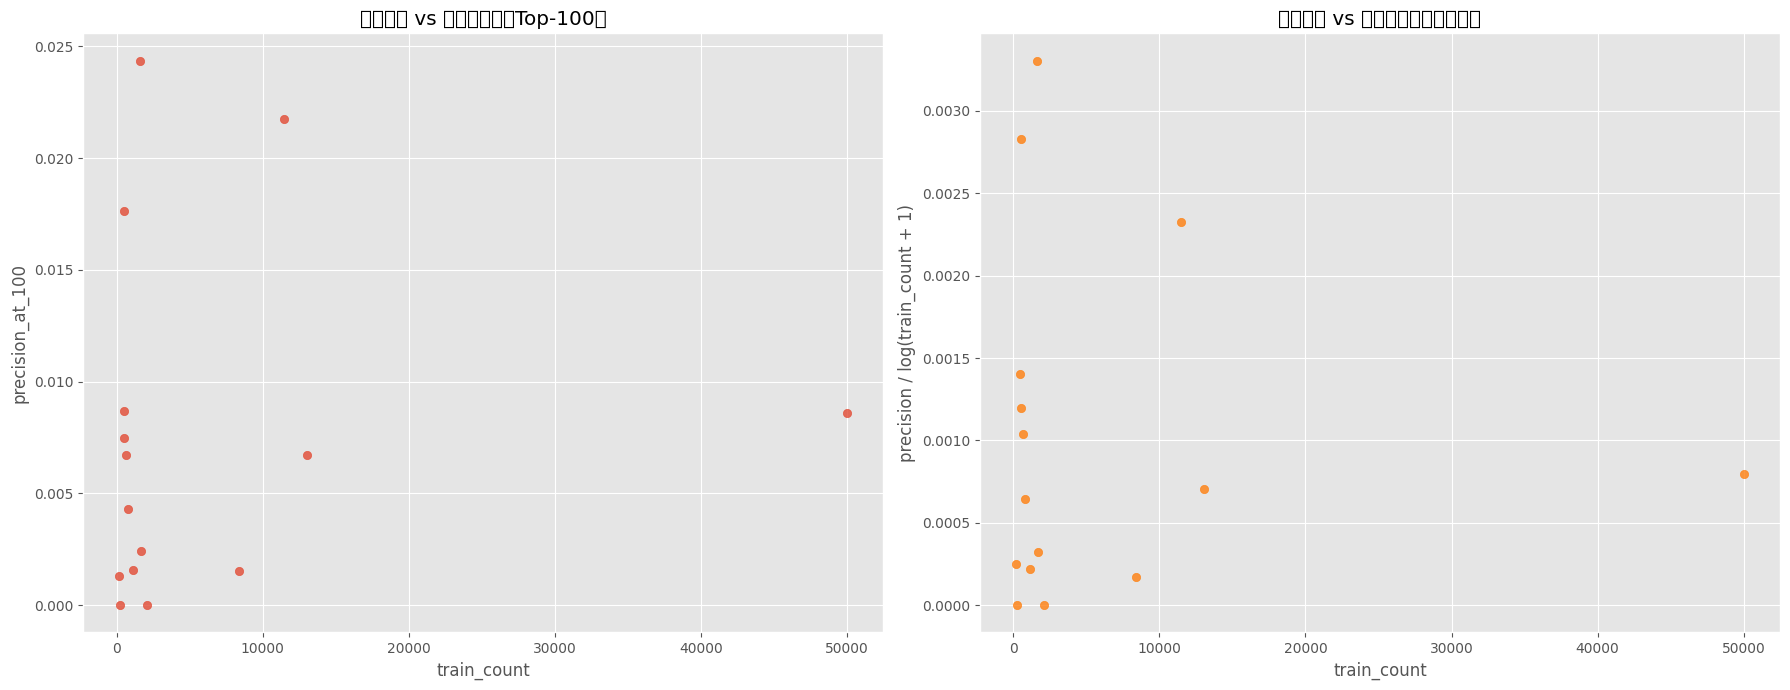

### 训练频次分桶汇总

,train_count_bucket,predicate_count,avg_precision_at_100,avg_recall_at_100,avg_ratio
0,0,15,NaN,NaN,NaN
1,1-10,0,NaN,NaN,NaN
2,11-100,0,NaN,NaN,NaN
3,101-1000,12,0.006598,0.177912,0.001052
4,>1000,23,0.008365,0.410201,0.000981


In [ ]:
def compute_rank_correlation(df: pd.DataFrame, x_col: str, y_col: str) -> pd.DataFrame:
    """输出 Pearson 与 Spearman 两种相关系数，便于快速判断频次和精度的关系。"""
    valid_df = df[[x_col, y_col]].replace([np.inf, -np.inf], np.nan).dropna()
    if len(valid_df) < 2:
        return pd.DataFrame([{"method": "pearson", "corr": np.nan}, {"method": "spearman", "corr": np.nan}])

    pearson_corr = valid_df[x_col].corr(valid_df[y_col], method="pearson")
    spearman_corr = valid_df[x_col].corr(valid_df[y_col], method="spearman")
    return pd.DataFrame([
        {"method": "pearson", "corr": pearson_corr},
        {"method": "spearman", "corr": spearman_corr},
    ])


if context is not None:
    predicate_metrics_df = context["tables"]["predicate_metrics_df"].copy()
    predicate_metrics_df["log_train_count"] = np.log1p(predicate_metrics_df["train_count"])
    predicate_metrics_df["train_count_bucket"] = pd.cut(
        predicate_metrics_df["train_count"],
        bins=[-0.1, 0, 10, 100, 1000, np.inf],
        labels=["0", "1-10", "11-100", "101-1000", ">1000"],
    )

    context["tables"]["predicate_train_freq_correlation_df"] = predicate_metrics_df

    show_message("### 相关系数")
    display(compute_rank_correlation(predicate_metrics_df, "train_count", "precision_at_100"))

    if plt is not None:
        fig, axes = plt.subplots(1, 2, figsize=(18, 7))
        axes[0].scatter(predicate_metrics_df["train_count"], predicate_metrics_df["precision_at_100"], alpha=0.8)
        axes[0].set_title("训练频次 vs 谓词精确率（Top-100）")
        axes[0].set_xlabel("train_count")
        axes[0].set_ylabel("precision_at_100")

        axes[1].scatter(predicate_metrics_df["train_count"], predicate_metrics_df["precision_div_log_train_count"], alpha=0.8, color="tab:orange")
        axes[1].set_title("训练频次 vs 频次归一化精确率比值")
        axes[1].set_xlabel("train_count")
        axes[1].set_ylabel("precision / log(train_count + 1)")

        plt.tight_layout()
        plt.show()
    else:
        print("当前环境缺少 matplotlib，已跳过散点图绘制。")

    bucket_summary_df = (
        predicate_metrics_df.groupby("train_count_bucket", dropna=False, as_index=False)
        .agg(
            predicate_count=("predicate_id", "size"),
            avg_precision_at_100=("precision_at_100", "mean"),
            avg_recall_at_100=("recall_at_100", "mean"),
            avg_ratio=("precision_div_log_train_count", "mean"),
        )
    )
    context["tables"]["train_bucket_summary_df"] = bucket_summary_df

    show_message("### 训练频次分桶汇总")
    display(bucket_summary_df)

## 10. 长尾 / 零样本 / 谓词混淆切片分析

这一节补充一些非常必要的切片：

- 长尾谓词是否显著更难
- 零训练频次 / 零样本三元组是否几乎全部失效
- 某个 GT 谓词最容易被混淆成哪些其他谓词

In [ ]:
if context is not None:
    predicate_metrics_df = context["tables"]["predicate_metrics_df"].copy()
    triplet_metrics_df = context["tables"]["triplet_metrics_df"].copy()
    confusion_df = context["tables"]["confusion_df"].copy()

    show_message("### 长尾谓词切片")
    tail_view = predicate_metrics_df.sort_values("train_count", ascending=True).head(20)[[
        "predicate_name", "train_count", "gt_count", "precision_at_100", "recall_at_100", "precision_div_log_train_count"
    ]]
    display(tail_view)

    show_message("### 零训练频次三元组")
    zero_train_triplet_df = triplet_metrics_df.loc[triplet_metrics_df["is_zero_train_triplet"]].sort_values(
        ["gt_count", "precision_at_100"], ascending=[False, False]
    )
    display(zero_train_triplet_df.head(20))

    show_message("### 官方零样本三元组")
    zero_shot_triplet_df = triplet_metrics_df.loc[triplet_metrics_df["is_zero_shot_triplet"]].sort_values(
        ["gt_count", "precision_at_100"], ascending=[False, False]
    )
    display(zero_shot_triplet_df.head(20))

    show_message("### 谓词混淆 Top 表（只统计 Top-100 未命中的 GT）")
    confusion_top_df = (
        confusion_df.loc[~confusion_df["matched_at_100"]]
        .groupby(["gt_predicate_name", "candidate_predicate_name"], as_index=False)
        .size()
        .rename(columns={"size": "count"})
        .sort_values("count", ascending=False)
    )
    context["tables"]["predicate_confusion_top_df"] = confusion_top_df
    display(confusion_top_df.head(30))

### 长尾谓词切片

,predicate_name,train_count,gt_count,precision_at_100,recall_at_100,precision_div_log_train_count
49,with,0,0,NaN,NaN,NaN
47,wearing,0,0,NaN,NaN,NaN
46,watching,0,0,NaN,NaN,NaN
45,walking on,0,0,NaN,NaN,NaN
44,walking in,0,0,NaN,NaN,NaN
43,using,0,0,NaN,NaN,NaN
42,under,0,0,NaN,NaN,NaN
41,to,0,0,NaN,NaN,NaN
40,standing on,0,0,NaN,NaN,NaN
39,sitting on,0,0,NaN,NaN,NaN


### 零训练频次三元组

,triplet_key,triplet_str,subject_name,predicate_name,object_name,gt_count,hit_at_20,hit_at_50,hit_at_100,pred_count_at_20,pred_count_at_50,pred_count_at_100,tp_at_20,tp_at_50,tp_at_100,avg_triplet_score,precision_at_20,recall_at_20,precision_at_50,recall_at_50,precision_at_100,recall_at_100,train_count,is_zero_shot_triplet,is_zero_train_triplet
62,"(149, 4, 94)",woman - along - pizza,woman,along,pizza,42.0,42.0,42.0,42.0,22.0,31.0,46.0,14.0,15.0,16.0,0.156809,0.636364,1.000000,0.483871,1.000000,0.347826,1.000000,0,False,True
20742,"(27, 7, 9)",cat - attached to - bed,cat,attached to,bed,41.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.000000,NaN,0.000000,NaN,0.000000,0,False,True
20743,"(115, 9, 99)",sign - belonging to - pole,sign,belonging to,pole,39.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.000000,NaN,0.000000,NaN,0.000000,0,False,True
63,"(78, 4, 94)",man - along - pizza,man,along,pizza,30.0,26.0,29.0,29.0,43.0,58.0,75.0,20.0,24.0,26.0,0.158544,0.465116,0.866667,0.413793,0.966667,0.346667,0.966667,0,False,True
82,"(52, 4, 73)",giraffe - along - leaf,giraffe,along,leaf,29.0,14.0,20.0,23.0,19.0,46.0,92.0,12.0,20.0,26.0,0.118462,0.631579,0.482759,0.434783,0.689655,0.282609,0.793103,0,False,True
179,"(73, 6, 136)",leaf - at - tree,leaf,at,tree,27.0,2.0,3.0,14.0,56.0,131.0,222.0,3.0,4.0,16.0,0.111984,0.053571,0.074074,0.030534,0.111111,0.072072,0.518519,0,False,True
24,"(37, 7, 9)",dog - attached to - bed,dog,attached to,bed,24.0,2.0,2.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,0.143464,1.000000,0.083333,1.000000,0.083333,1.000000,0.083333,0,False,True
75,"(20, 4, 94)",boy - along - pizza,boy,along,pizza,23.0,16.0,22.0,22.0,10.0,24.0,27.0,4.0,8.0,8.0,0.166819,0.400000,0.695652,0.333333,0.956522,0.296296,0.956522,0,False,True
129,"(91, 15, 124)",person - flying in - street,person,flying in,street,23.0,5.0,9.0,10.0,39.0,55.0,69.0,5.0,9.0,11.0,0.113136,0.128205,0.217391,0.163636,0.391304,0.159420,0.434783,0,False,True
20744,"(78, 3, 149)",man - against - woman,man,against,woman,22.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.000000,NaN,0.000000,NaN,0.000000,0,False,True


### 官方零样本三元组

,triplet_key,triplet_str,subject_name,predicate_name,object_name,gt_count,hit_at_20,hit_at_50,hit_at_100,pred_count_at_20,pred_count_at_50,pred_count_at_100,tp_at_20,tp_at_50,tp_at_100,avg_triplet_score,precision_at_20,recall_at_20,precision_at_50,recall_at_50,precision_at_100,recall_at_100,train_count,is_zero_shot_triplet,is_zero_train_triplet
131,"(149, 4, 49)",woman - along - food,woman,along,food,8.0,8.0,8.0,8.0,12.0,17.0,20.0,3.0,3.0,3.0,0.142975,0.25,1.0,0.176471,1.0,0.15,1.0,0,True,True
102,"(37, 4, 49)",dog - along - food,dog,along,food,3.0,3.0,3.0,3.0,2.0,3.0,5.0,1.0,1.0,1.0,0.128746,0.50,1.0,0.333333,1.0,0.20,1.0,0,True,True
318,"(56, 4, 49)",guy - along - food,guy,along,food,1.0,0.0,0.0,0.0,1.0,3.0,4.0,0.0,0.0,0.0,0.142664,0.00,0.0,0.000000,0.0,0.00,0.0,0,True,True
330,"(76, 9, 22)",light - belonging to - building,light,belonging to,building,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.100736,NaN,0.0,0.000000,0.0,0.00,0.0,0,True,True
21044,"(57, 3, 43)",hair - against - eye,hair,against,eye,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,NaN,0.0,NaN,0.0,0,True,True
21108,"(78, 10, 41)",man - between - elephant,man,between,elephant,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,NaN,0.0,NaN,0.0,0,True,True
520,"(3, 8, 9)",arm - behind - bed,arm,behind,bed,0.0,0.0,0.0,0.0,6.0,8.0,10.0,0.0,0.0,0.0,0.124179,0.00,NaN,0.000000,NaN,0.00,NaN,0,True,True
529,"(3, 8, 22)",arm - behind - building,arm,behind,building,0.0,0.0,0.0,0.0,6.0,11.0,13.0,0.0,0.0,0.0,0.095755,0.00,NaN,0.000000,NaN,0.00,NaN,0,True,True
1172,"(8, 4, 26)",bear - along - car,bear,along,car,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.121100,0.00,NaN,0.000000,NaN,0.00,NaN,0,True,True
1311,"(9, 7, 22)",bed - attached to - building,bed,attached to,building,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.137589,0.00,NaN,0.000000,NaN,0.00,NaN,0,True,True


### 谓词混淆 Top 表（只统计 Top-100 未命中的 GT）

,gt_predicate_name,candidate_predicate_name,count
51,attached to,behind,231
16,across,covered in,52
79,between,belonging to,51
26,against,behind,48
9,across,above,43
32,against,eating,41
71,belonging to,covered in,38
48,attached to,along,35
80,between,carrying,32
78,between,behind,31


## 11. 代表性案例可视化

这一节提供一个简单但实用的案例查看器：

- 支持查看某个谓词下的高置信伪阳性
- 支持查看某个谓词下的典型漏检
- 支持查看某个谓词下的正确预测

如果 `visual_info.json` 或图片文件缺失，函数会自动降级为只显示表格信息。

In [ ]:
def show_image_if_possible(img_file: Optional[str], title: str = "") -> None:
    """尽量显示图片；如果文件不存在，则打印说明。"""
    if not ENABLE_IMAGE_VIS:
        print("图片显示已关闭。")
        return
    if plt is None:
        print("当前环境缺少 matplotlib，无法直接显示图片。")
        return
    if not img_file:
        print("当前样本没有可用的图片路径。")
        return
    img_path = Path(img_file)
    if not img_path.exists():
        print(f"图片不存在: {img_path}")
        return
    image = Image.open(img_path).convert("RGB")
    plt.figure(figsize=(10, 8))
    plt.imshow(image)
    plt.axis("off")
    plt.title(title)
    plt.show()


def show_predicate_cases(predicate_name: str, case_type: str = "false_positive", topk: int = 100, num_cases: int = 3) -> pd.DataFrame:
    """
    按谓词查看代表性样本。

    case_type 支持：
    - false_positive
    - missed_gt
    - correct_prediction
    """
    if context is None:
        print("请先完成前面的数据加载与分析。")
        return pd.DataFrame()

    pred_df = context["tables"]["pred_df"]
    gt_df = context["tables"]["gt_df"]

    if case_type == "false_positive":
        case_df = pred_df.loc[
            (pred_df["predicate_name"] == predicate_name)
            & pred_df[f"is_top_{topk}"]
            & ~pred_df[f"correct_at_{topk}"]
        ].sort_values("triplet_score", ascending=False)
    elif case_type == "missed_gt":
        case_df = gt_df.loc[
            (gt_df["predicate_name"] == predicate_name)
            & ~gt_df[f"matched_at_{topk}"]
        ].copy()
    elif case_type == "correct_prediction":
        case_df = pred_df.loc[
            (pred_df["predicate_name"] == predicate_name)
            & pred_df[f"correct_at_{topk}"]
        ].sort_values("triplet_score", ascending=False)
    else:
        raise ValueError("case_type 仅支持 false_positive / missed_gt / correct_prediction")

    preview_df = case_df.head(num_cases)
    display(preview_df)

    for _, row in preview_df.iterrows():
        title = f"{case_type} | {row.get('triplet_str', 'N/A')} | image_id={row['image_id']}"
        show_image_if_possible(row.get("img_file"), title=title)

    return preview_df


if context is not None and len(context["tables"]["predicate_metrics_df"]) > 0:
    error_predicates = (
        context["tables"]["predicate_metrics_df"]
        .sort_values(["precision_at_100", "gt_count"], ascending=[True, False])
        .head(5)["predicate_name"]
        .tolist()
    )
    show_message("### 建议优先检查的低精度谓词")
    display(pd.DataFrame({"predicate_name": error_predicates}))
    print("示例：show_predicate_cases(error_predicates[0], case_type='false_positive', topk=100, num_cases=SHOW_CASES_PER_PREDICATE)")

### 建议优先检查的低精度谓词

,predicate_name
0,against
1,across
2,covered in
3,above
4,carrying


示例：show_predicate_cases(error_predicates[0], case_type='false_positive', topk=100, num_cases=SHOW_CASES_PER_PREDICATE)


## 12. 结果导出

最后一节把最重要的表导出为 CSV，方便你做后续筛选、画图或写报告。

默认导出：

- `predicate_metrics.csv`
- `triplet_metrics.csv`
- `missed_gt_triplets.csv`
- `false_positive_triplets.csv`
- `predicate_train_freq_correlation.csv`

In [ ]:
if context is not None:
    export_dir = context["export_dir"]
    export_dir.mkdir(parents=True, exist_ok=True)

    export_map = {
        "predicate_metrics.csv": context["tables"].get("predicate_metrics_df"),
        "triplet_metrics.csv": context["tables"].get("triplet_metrics_df"),
        "missed_gt_triplets.csv": context["tables"].get("missed_gt_top100_df"),
        "false_positive_triplets.csv": context["tables"].get("false_positive_top100_df"),
        "predicate_train_freq_correlation.csv": context["tables"].get("predicate_train_freq_correlation_df"),
    }

    exported_files = []
    for file_name, df in export_map.items():
        if df is None or len(df) == 0:
            continue
        out_path = export_dir / file_name
        df.to_csv(out_path, index=False, encoding="utf-8-sig")
        exported_files.append(str(out_path))

    show_message("### 导出完成")
    display(pd.DataFrame({"exported_file": exported_files}))

### 导出完成

,exported_file
0,/workspace/ccloud/sf/SDSGG/output/baseline/inf...
1,/workspace/ccloud/sf/SDSGG/output/baseline/inf...
2,/workspace/ccloud/sf/SDSGG/output/baseline/inf...
3,/workspace/ccloud/sf/SDSGG/output/baseline/inf...
4,/workspace/ccloud/sf/SDSGG/output/baseline/inf...
